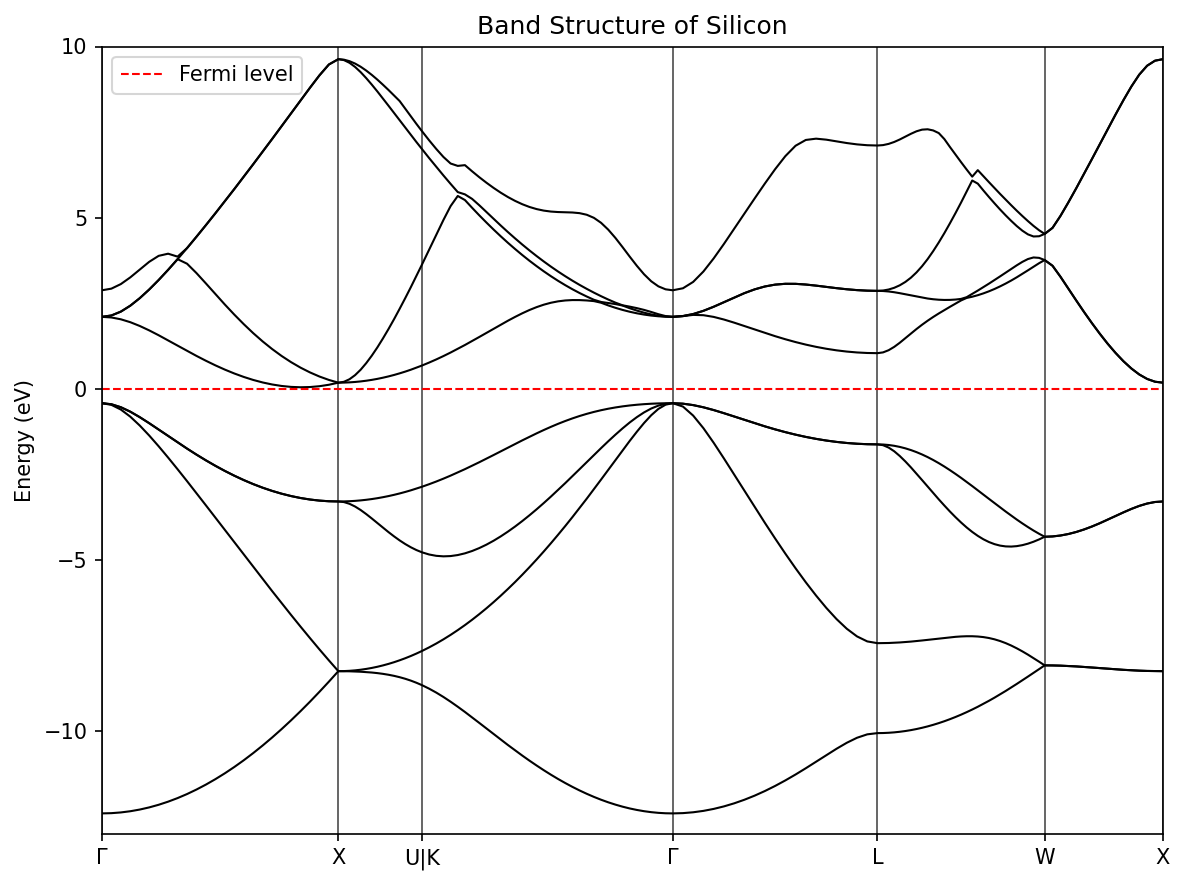

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Load the band structure data
data = np.loadtxt('bands_pp.dat.gnu')

# Fermi energy from dos/nscf.out
fermi_energy = 6.5627

# Number of bands
nbnd = 8
nk = len(data) // nbnd  # 696 // 8 = 87

# Extract k-points (same for all bands)
k = data[:nk, 0]

# Reshape the energy data into bands
bands = np.reshape(data[:, 1], (nbnd, nk))

# Shift energies so Fermi energy is at 0
bands = bands - fermi_energy

# High symmetry points from bands_pp.out
high_symmetry_points = [0.0000, 0.7071, 0.9571, 1.7071, 2.3195, 2.8195, 3.1730]
labels = ['Γ', 'X', 'U|K', 'Γ', 'L', 'W', 'X']

# Plot the bands
plt.figure(figsize=(8, 6))
for band in bands:
    plt.plot(k, band, color='black', linewidth=1)

# Add vertical lines at high symmetry points
for point in high_symmetry_points:
    plt.axvline(point, color='black', linestyle='-', alpha=0.7, linewidth=0.8)

# Add Fermi level
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Fermi level')

# Set x-ticks and labels
plt.xticks(high_symmetry_points, labels)
plt.xlim(min(k), max(k))
plt.ylim(-13, 10)  # Adjust as needed
plt.ylabel('Energy (eV)')
plt.title('Band Structure of Silicon')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()